In [32]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
class MNISTDataset(Dataset):
    def __init__(self, root='data/', train=True, transforms=None):
        self.data = datasets.MNIST(root=root, train=train, transform=transforms)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image, label = self.data[idx]
        return image, label
    
    def get_datas(self):
        return self.data.data
    
    def get_labels(self):
        return self.data.targets.numpy()

In [3]:
train_dataset = MNISTDataset(train=True, transforms=transforms.ToTensor())
test_dataset = MNISTDataset(train=False, transforms=transforms.ToTensor())

In [4]:
class LeNet(nn.Module):
    """The LeNet-5 model."""
    def __init__(self, num_classes, lr):
        super().__init__()
        self.lr = lr
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Sigmoid(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, X):
        return self.net(X)
    
    def apply_init(self, inputs, init=None):
        self.forward(*inputs)
        if init is not None:
            self.net.apply(init)

In [52]:
def init_cnn(module):
    """Initialize weights for CNNs."""
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)

In [26]:
model = LeNet(num_classes=10, lr=0.1)

In [53]:
# Metrics
optimizer = torch.optim.SGD(model.parameters(), lr = model.lr)
criterion = torch.nn.CrossEntropyLoss()
batch_size = 128

In [54]:
datas = train_dataset.get_datas()
labels = train_dataset.get_labels()

In [55]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

LeNet(
  (net): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Sigmoid()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Sigmoid()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=400, out_features=120, bias=True)
    (8): Sigmoid()
    (9): Linear(in_features=120, out_features=84, bias=True)
    (10): Sigmoid()
    (11): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [31]:
epochs = 30
Loss = []

model.apply_init([next(iter(train_loader))[0].to(device)], init_cnn)

for epoch in range(epochs):
    epoch_loss = 0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    Loss.append(epoch_loss / len(train_loader))
    print(f'Epoch: {epoch + 1}/{epochs}. Loss: {Loss[-1]:.4f}')

Epoch: 1/20. Loss: 2.3071
Epoch: 2/20. Loss: 2.3052
Epoch: 3/20. Loss: 2.3040
Epoch: 4/20. Loss: 2.3026
Epoch: 5/20. Loss: 2.2996
Epoch: 6/20. Loss: 2.2888
Epoch: 7/20. Loss: 2.1290
Epoch: 8/20. Loss: 1.1675
Epoch: 9/20. Loss: 0.7125
Epoch: 10/20. Loss: 0.5247
Epoch: 11/20. Loss: 0.4318
Epoch: 12/20. Loss: 0.3794
Epoch: 13/20. Loss: 0.3441
Epoch: 14/20. Loss: 0.3162
Epoch: 15/20. Loss: 0.2928
Epoch: 16/20. Loss: 0.2722
Epoch: 17/20. Loss: 0.2537
Epoch: 18/20. Loss: 0.2366
Epoch: 19/20. Loss: 0.2216
Epoch: 20/20. Loss: 0.2080


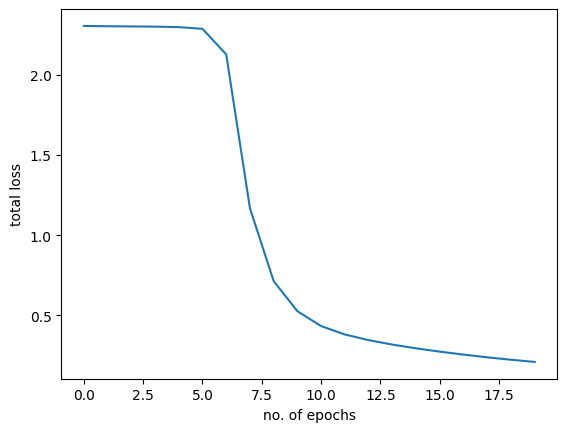

In [33]:
plt.plot(Loss)
plt.xlabel('no. of epochs')
plt.ylabel('total loss')
plt.show()

In [70]:
def predict(model, test_dataset):
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, labels in test_dataset:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            predictions.extend(predicted.cpu())
    return predictions

In [71]:
predictions = predict(model, test_loader)
print(predictions[:10])

[tensor(7), tensor(2), tensor(1), tensor(0), tensor(4), tensor(1), tensor(4), tensor(4), tensor(6), tensor(9)]


In [73]:
datas_test = test_dataset.get_datas()
labels_test = test_dataset.get_labels()

In [74]:
preds = np.array(predictions, dtype=np.int32)
acc_test = float((preds == labels_test).sum()) / len(labels_test)
print('Test accuracy: {}'.format(acc_test))

Test accuracy: 0.9414


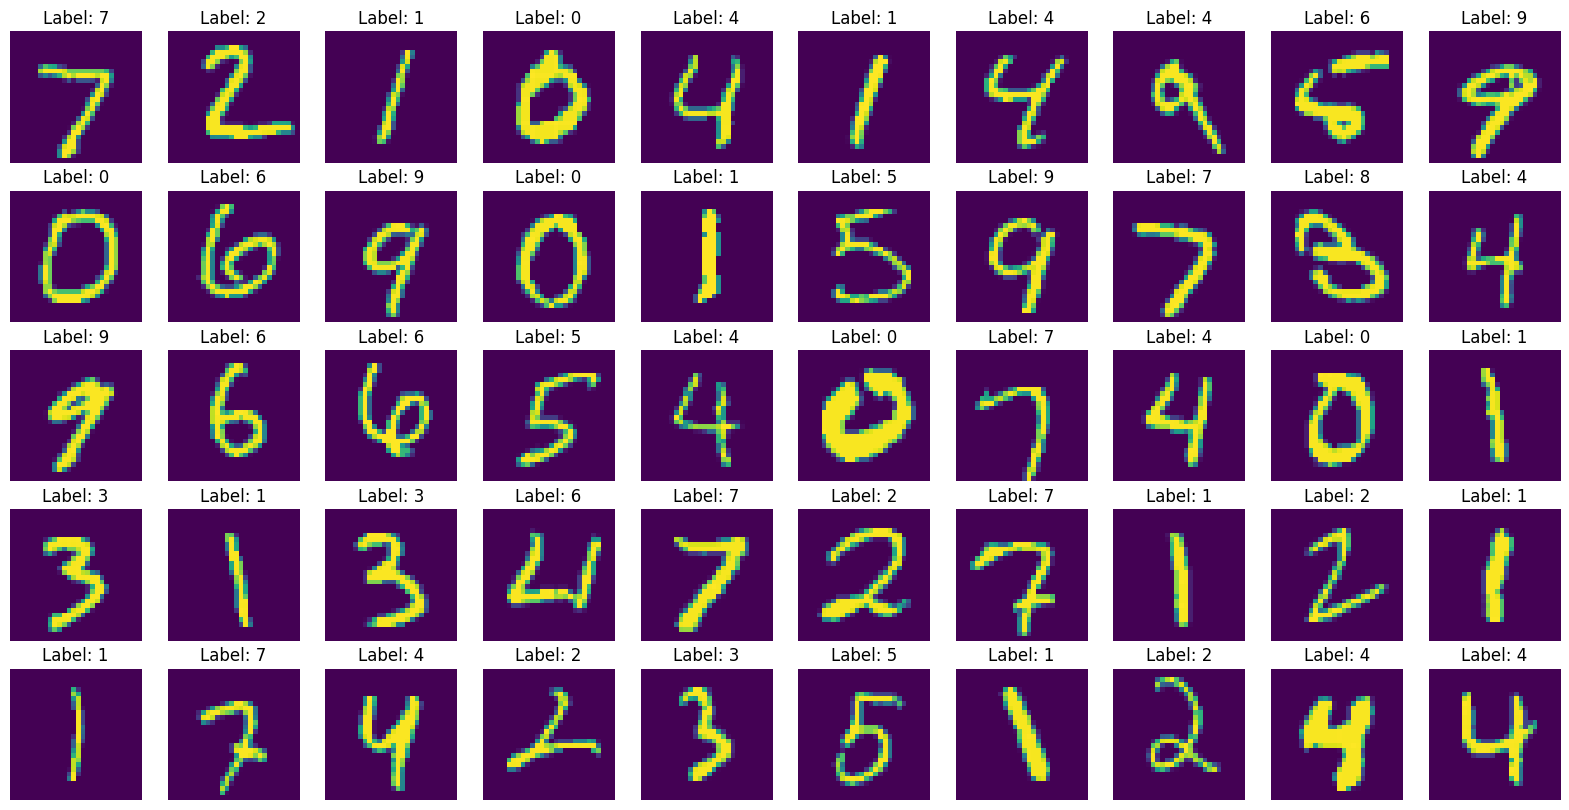

In [39]:
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(datas_test[i].squeeze(0))
    ax.set_title(f"Label: {predictions[i].item()}")
    ax.axis("off")

plt.show()

In [40]:
# Directory to saved folder
saved_file_path = 'data/saved/'

In [43]:
torch.save(model.net.state_dict(), saved_file_path + 'LeNet.params')

In [57]:
class LeNet_Improved(nn.Module):
    """The LeNet-5 model."""
    def __init__(self, num_classes, lr):
        super().__init__()
        self.lr = lr
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.ReLU(),
            nn.LazyLinear(84), nn.ReLU(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, X):
        return self.net(X)
    
    def apply_init(self, inputs, init=None):
        self.forward(*inputs)
        if init is not None:
            self.net.apply(init)

In [58]:
model_improved = LeNet_Improved(num_classes=10, lr=0.01)
model_improved.to(device)

LeNet_Improved(
  (net): Sequential(
    (0): LazyConv2d(0, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): LazyConv2d(0, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): LazyLinear(in_features=0, out_features=120, bias=True)
    (8): ReLU()
    (9): LazyLinear(in_features=0, out_features=84, bias=True)
    (10): ReLU()
    (11): LazyLinear(in_features=0, out_features=10, bias=True)
  )
)

In [59]:
def init_cnn_relu(module):
    """Initialize weights for CNNs but with ReLU activations."""
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')

In [60]:
epochs = 30
Loss = []

model_improved.apply_init([next(iter(train_loader))[0].to(device)], init_cnn_relu)    

for epoch in range(epochs):
    epoch_loss = 0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_improved(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    Loss.append(epoch_loss / len(train_loader))
    print(f'Epoch: {epoch + 1}/{epochs}. Loss: {Loss[-1]:.4f}')

Epoch: 1/30. Loss: 2.3238
Epoch: 2/30. Loss: 2.3238
Epoch: 3/30. Loss: 2.3239
Epoch: 4/30. Loss: 2.3238
Epoch: 5/30. Loss: 2.3238
Epoch: 6/30. Loss: 2.3239
Epoch: 7/30. Loss: 2.3239
Epoch: 8/30. Loss: 2.3238
Epoch: 9/30. Loss: 2.3238
Epoch: 10/30. Loss: 2.3238
Epoch: 11/30. Loss: 2.3239
Epoch: 12/30. Loss: 2.3239
Epoch: 13/30. Loss: 2.3238
Epoch: 14/30. Loss: 2.3239
Epoch: 15/30. Loss: 2.3238
Epoch: 16/30. Loss: 2.3239
Epoch: 17/30. Loss: 2.3238
Epoch: 18/30. Loss: 2.3239
Epoch: 19/30. Loss: 2.3238
Epoch: 20/30. Loss: 2.3239
Epoch: 21/30. Loss: 2.3238
Epoch: 22/30. Loss: 2.3239
Epoch: 23/30. Loss: 2.3238
Epoch: 24/30. Loss: 2.3238
Epoch: 25/30. Loss: 2.3238
Epoch: 26/30. Loss: 2.3239
Epoch: 27/30. Loss: 2.3239
Epoch: 28/30. Loss: 2.3239
Epoch: 29/30. Loss: 2.3238
Epoch: 30/30. Loss: 2.3239
